In [1]:
# in case of using colab or any other online platform run this cell

# !git clone https://github.com/Pooria90/EEG-Motor-Imagery-Analysis.git
import os
os.chdir('/Users/rishabhkumar/Kernel-Experiments/betaprime-experiments')

# Data

## Download dataset

In [2]:
# from datautils import downloader

# path  = 'data'
# dpath = downloader(path, subjects=list(range(1,10)))
path = '/Users/rishabhkumar/mne_data/MNE-bnci-data/database/data-sets/001-2014'


## Extracting .mat files

## Why is the dimension (288, 22, 1000)?

`x_train` contains the EEG signal across 22 channels for 1000 time steps. 288 is the number of trials for the particular individual. 

In [5]:
!echo "Current working directory: $(pwd)"
from datautils import mat_extractor

tr_name = 'A01T.mat'
te_name = 'A01E.mat'

x_train, y_train = mat_extractor(path=path + '/' + tr_name, bpf_dict={'apply': True, 'fs': 250, 'lc':8, 'hc':35, 'order':5})
x_test , y_test  = mat_extractor(path=path + '/' + te_name)

print (f'*** Shapes ***\nx_train:\t{x_train.shape}\ny_train:\t{y_train.shape}')
print (f'x_test:\t\t{x_test.shape}\ny_test:\t\t{y_test.shape}')

Current working directory: /Users/rishabhkumar/BCI-data/preprocessing-bci-2a
*** Shapes ***
x_train:	(288, 22, 1000)
y_train:	(288,)
x_test:		(288, 22, 1000)
y_test:		(288,)


In [4]:
# How does the y_train and y_test look like? 
# print(f'\ny_train:\n{y_train[:100]}')

# Preprocessing : Barachant et. al. 
In Barachant et. al.'s paper on Kernel SVM applied on the SPD manifold, the following procedure to pre-process the data was used: 
1. The 22 channels (excluding EOG channels, only EEG ones) were used. 
2. A 8-35 Hz band-pass filter, using a 5-th order Butterworth filter was used. 
3. The dataset is composed of 9 subjects who pefformed 576 trials of right-hand (RH), left-hand (LH), tongue (TO) and both feet (BF) motor imagery (i.e. 144 trials per class) in two different sessions, of 288 trials each, recorded on different days. 

More information about the trials (through the dataset white-paper): 
> At the beginning of a trial (t = 0 s), a fixation cross appeared on the black screen. In addition, a short acoustic warning tone was presented. After two seconds (t = 2 s), a cue in the form of an arrow pointing either to the left, right, down or up (corresponding to one of the four classes left hand, right hand, foot or tongue) appeared and stayed on the screen for 1.25 s. This prompted the subjects to perform the desired motor imagery task. No feedback was provided. The subjects were ask to carry out the motor imagery task until the fixation cross disappeared from the screen at t = 6 s.

Since the sampling frequency is of `250 Hz` and the signal of interest spans `4 secs`, we need to start from the time stamp `250 * 2 = 500` and end at `250 * 6 = 1500`, which represents the number of samples stored in each `epoch`. 

## Covariance matrix calculation for each trial 
For each signal $\{X_t\}_{t \in T}$, $X \in \mathbb{R}^{E \times T}$ we can process these into covariance matrices, by the Sample Covariance Matrix (SCM) estimator,

$$ 
\Sigma_{\mathrm{p}} = \frac{1}{T-1} X X' \quad (X' \implies \mathrm{Transpose \, of \, X})
$$

 on the space $SPD(E)$, the space of Symmetric Positive Definite $E \times E$ matrices. 

In [6]:
# Calculate the covariance matrices for the signal 
from datautils import multi_signal_cov_calculator

cov_train = multi_signal_cov_calculator(x_train, type='oas')

In [7]:
import numpy as np
training_files = [f for f in os.listdir(path) if f.startswith('A0') and f.endswith('T.mat')]
print(f'Training files found: {training_files}')
cov_blocks = []
label_blocks = []

for f in training_files:
    x_tr, y_tr = mat_extractor(path=path+'/'+f,
                               bpf_dict={'apply': True, 'fs':250,'lc':8,'hc':35,'order':5})
    cov_blocks.append(multi_signal_cov_calculator(x_tr))
    label_blocks.append(y_tr)

# now stack into one big array of shape (n_trials_total, E, E)
cov_train_all = np.concatenate(cov_blocks, axis=0)
y_train_all = np.concatenate(label_blocks,  axis=0)

print(cov_train_all.shape, y_train_all.shape)

Training files found: ['A08T.mat', 'A04T.mat', 'A05T.mat', 'A09T.mat', 'A02T.mat', 'A03T.mat', 'A01T.mat', 'A06T.mat', 'A07T.mat']
(2496, 22, 22) (2496,)


In [8]:
# What is the scale of the covariance matrices?
# Just print the first one
print(f'Covariance matrix shape: {cov_train_all[0]}')
# Check if this is a valid covariance matrix
def is_valid_covariance_matrix(cov_matrix):
    if cov_matrix.ndim != 2:
        return False
    if cov_matrix.shape[0] != cov_matrix.shape[1]:
        return False
    if not np.allclose(cov_matrix, cov_matrix.T):
        return False
    if np.any(np.linalg.eigvals(cov_matrix) <= 0):
        return False
    return True
# Check the first covariance matrix
def is_highlycorrelated(cov_matrix, threshold=0.9):
    corr_matrix = np.corrcoef(cov_matrix)
    return np.any(np.abs(corr_matrix) > threshold)

def condition_number(cov_matrix):
    return np.linalg.cond(cov_matrix)
print(f'Condition number of the first covariance matrix: {condition_number(cov_train_all[0])}')

print(f'Is the first covariance matrix valid? {is_valid_covariance_matrix(cov_train_all[0])}')
print(f'Is the first covariance matrix highly correlated? {is_highlycorrelated(cov_train_all[0])}')

np.linalg.det(cov_train_all[0])  # Check if the determinant is non-zero

Covariance matrix shape: [[ 0.80060129  0.7739207   0.74450482  0.59954332  0.73510678  0.81625071
   0.59700606  0.49510153  0.28366592  0.17308027  0.11547049  0.05318901
  -0.07423632 -0.09548749 -0.14391916 -0.25400566 -0.34910965 -0.28160877
  -0.05983721 -0.27304711 -0.22980675 -0.19276318]
 [ 0.7739207   0.8983087   0.78260171  0.57613761  0.68829686  0.74874382
   0.80887773  0.69756692  0.37534004  0.19960119  0.08799246  0.01072732
  -0.11681915  0.07584693 -0.14758586 -0.30792324 -0.43104126 -0.39200883
  -0.05348732 -0.27827247 -0.27109532 -0.17614804]
 [ 0.74450482  0.78260171  0.76065845  0.61393619  0.72979769  0.79389929
   0.63522413  0.57659643  0.389341    0.26877451  0.21072006  0.13019874
   0.02116293  0.05631484  0.02501105 -0.08072781 -0.17778375 -0.13588533
   0.07545764 -0.14807011 -0.1192263  -0.10241349]
 [ 0.59954332  0.57613761  0.61393619  0.57956162  0.64976464  0.71383954
   0.3828081   0.39710671  0.3441744   0.31522804  0.29455508  0.23583035
   0.128

3.579097323738184e-32

In [23]:
cov_test_all = []
label_test_blocks = []
test_files = [f for f in os.listdir(path) if f.startswith('A0') and f.endswith('E.mat')]
for f in test_files:
    x_t, y_t = mat_extractor(path=path + '/' + f)
    cov_test_all.append(multi_signal_cov_calculator(x_t))
    label_test_blocks.append(y_t)

cov_test_all = np.concatenate(cov_test_all, axis=0)
y_test_all   = np.concatenate(label_test_blocks, axis=0)

print(cov_test_all.shape, y_test_all.shape)



(2592, 22, 22) (2592,)


In [29]:
from pyriemann.tangentspace import TangentSpace
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
ts = TangentSpace(metric='riemann')
resul_train = ts.fit(cov_train_all)

# Train a classifier on the training data
svm  = SVC(kernel='rbf', C=5.0, gamma='auto', random_state=42)
clf = make_pipeline(ts, svm)
clf.fit(cov_train_all, y_train_all)

# Evaluate the classifier on the training data
accuracy_train = clf.score(cov_train_all, y_train_all)
print(f'Accuracy of the classifier on the training data: {accuracy_train * 100:.2f}%')

# Evaluate the classifier on the test data

accuracy = clf.score(cov_test_all, y_test_all)
print(f'Accuracy of the classifier on the test data: {accuracy * 100:.2f}% ± {np.std(accuracy) * 100:.2f}%')

Accuracy of the classifier on the training data: 74.40%
Accuracy of the classifier on the test data: 37.89% ± 0.00%


In [27]:
from betaprime_python import BetaprimeKernel, BetaprimeKernelSklearnAdapter, logBetaPrimeKernelSklearnAdapter
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
bp = BetaprimeKernel(alpha = 1)
# bp_sklearn = BetaprimeKernelSklearnAdapter(alpha = 22.5)
logbp_sklearn = logBetaPrimeKernelSklearnAdapter(alpha = 22.5)
# transformed_cov_train = bp_sklearn(cov_train_all, cov_train_all)

# print(f'Training acc (BetaPrime): {clf_bp.score(cov_train_all, y_train_all)*100:.2f}%')
# print(f'Test     acc (BetaPrime): {clf_bp.score(cov_test_all,  y_test_all)*100:.2f}%')

In [ ]:
# clf_bp.fit(transformed_cov_train, y_train_all)

# simply plug the adapter into SVC and fit
svc_bp = SVC(kernel=logbp_sklearn, C=1.0, random_state=42)
svc_bp.fit(cov_train_all, y_train_all)

# evaluate on test
print(f"Test accuracy: {svc_bp.score(cov_test_all, y_test_all)*100:.2f}%")



Computing log kernel matrix:  33%|███▎      | 813/2496 [00:30<01:03, 26.32it/s]


KeyboardInterrupt: 

In [12]:
save = bp_sklearn(cov_train_all[:500], cov_train_all[:500])
# Fix the scaling issue 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Fit the scaler on the training data
scaler.fit(save)
# Transform the training data
transformed_cov_train = scaler.transform(save)
# Transform the test data

NameError: name 'bp_sklearn' is not defined

In [17]:
from betaprime_python import BetaprimeKernel, BetaprimeKernelSklearnAdapter, logBetaPrimeKernelSklearnAdapter

K = logbp_sklearn(cov_test_all[0:500], cov_test_all[0:500])
np.linalg.cond(K)

# Compute the eigenvalues and eigenvectors of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(K)

Computing log kernel matrix: 100%|██████████| 500/500 [00:03<00:00, 155.48it/s]


In [20]:
np.exp(K[1, 1])

1.4110812570364393e-296

In [41]:
print(bp_sklearn.gamma_const)

0.9735042655627757


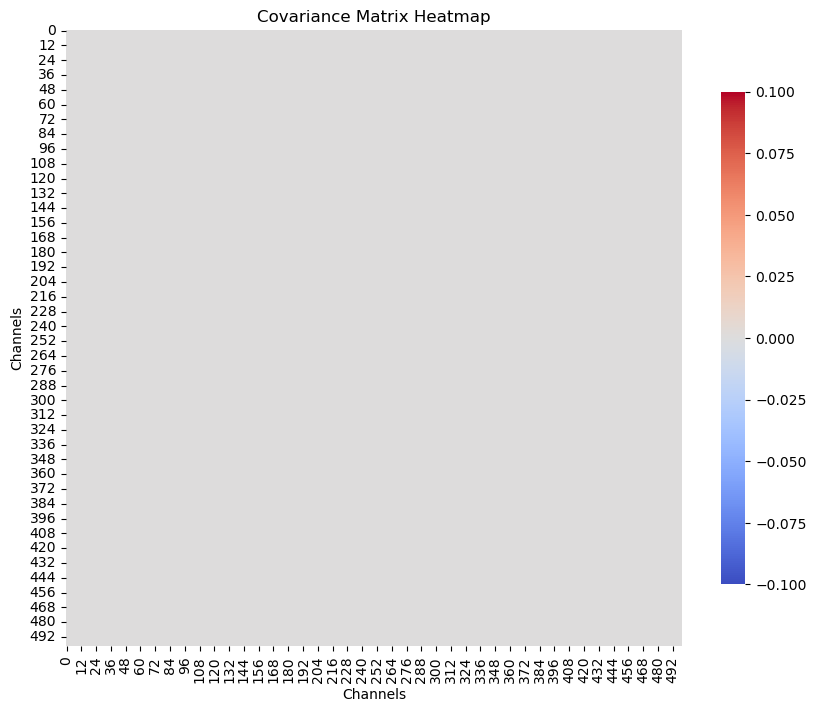

In [48]:
# print the heatmap of the covariance matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(transformed_cov_train, annot=False, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Covariance Matrix Heatmap')
plt.xlabel('Channels')
plt.ylabel('Channels')
plt.show()

In [31]:
print(f'Training acc (BetaPrime): {clf_bp.score(cov_train_all, y_train_all)*100:.2f}%')


Computing kernel matrix: 100%|██████████| 2496/2496 [01:02<00:00, 40.14it/s]


Training acc (BetaPrime): 25.00%


In [32]:
print(f'Test     acc (BetaPrime): {clf_bp.score(cov_test_all,  y_test_all)*100:.2f}% ± {np.std(clf_bp.score(cov_test_all,  y_test_all))*100:.2f}%')

Computing kernel matrix: 100%|██████████| 2592/2592 [01:04<00:00, 40.05it/s]


Test     acc (BetaPrime): 25.00% ± 0.00%


In [26]:
bp_kernel = BetaprimeKernel(alpha=3.0)
print(f'BetaPrime raw kernel: {bp_kernel}')

# 2) wrap it so that fit/transform produce an (n_samples × n_samples) Gram matrix
adapter = BetaPrimeKernelSklearnAdapter(alpha = 3.0)

BetaPrime raw kernel: <betaprime.BetaprimeKernel object at 0x31099fa60>


# Binary classification using betaprime kernel 
Since CSP is designed for binary classification, we have evaluated the average performance per subject, for all 6 possible pairs of mental tasks: {LH/RH, LH/BF, LH/TO, RH/BF, RH/TO, BF/TO}

- Event Type 769: Cue onset left (Class 1)
- Event Type 770: Cue onset right (Class 2)
- Event Type 771: Cue onset foot (Class 3)
- Event Type 772: Cue onset tongue (Class 4)

In [30]:
from sklearn.model_selection import GridSearchCV

# Prepare binary train/test sets for Left (1) vs Right (2)
mask_tr = np.isin(y_train_all, [1, 2])
x_tr_bin = cov_train_all[mask_tr]
y_tr_bin = y_train_all[mask_tr]

mask_te = np.isin(y_test_all, [1, 2])
x_te_bin = cov_test_all[mask_te]
y_te_bin = y_test_all[mask_te]

# Pipeline with Riemannian tangent‐space mapping + RBF‐SVC
pipe = make_pipeline(
    SVC(kernel=BetaprimeKernelSklearnAdapter(alpha = 1.0), random_state=42)
)


In [31]:
# Check the accuracy on the test data
mask_test = np.isin(y_test_all, [1, 2])
x_test_binary = cov_test_all[mask_test]
y_test_binary = y_test_all[mask_test]
accuracy_test_binary = clf_binary_rbf.score(x_test_binary, y_test_binary)


NameError: name 'clf_binary_rbf' is not defined

## cropping for augmentation

In [ ]:
# TODO: Efficently compute the Gram matrix
bp(cov_train_all, cov_train_all)  # compute the Gram matrix

: 

In [ ]:
#@title: Don't need to run this cell for the betaprime kernel, as augmentation is not required.
from datautils import cropper

x_train, y_train = cropper(x_train, y_train, window=500, step=500)
x_test , y_test  = cropper(x_test , y_test, window=500, step=500)

print (f'*** Shapes ***\nx_train:\t{x_train.shape}\ny_train:\t{y_train.shape}')
print (f'x_test:\t\t{x_test.shape}\ny_test:\t\t{y_test.shape}')

## Split for validation

In [ ]:
from sklearn.model_selection import train_test_split

x_tr, x_va, y_tr, y_va = train_test_split(x_train, y_train-1, test_size=0.25, random_state=216, shuffle=True)

print (x_tr.shape, x_va.shape)

# EEGNet

In [ ]:
import numpy as np
import torch

# adding a second dimension, becasue we have Conv2d in our structure
x_tr = np.expand_dims(x_tr, axis=1)
x_va = np.expand_dims(x_va, axis=1)

x_tr, x_va, y_tr, y_va = map(torch.tensor, [x_tr, x_va, y_tr, y_va])
print (x_tr.shape, x_va.shape)

## Simple training loop

In [ ]:
from models import EEGNet
from fitting import train

if torch.cuda.is_available():
    target_device = 'cuda'
else:
    target_device = 'cpu'
    
model = EEGNet().to(target_device)
hist = train(model, x_tr, y_tr, x_va, y_va, batch_size=144, epochs=50, learning_rate=0.001, period=10)

## Training with early-stopping

In [ ]:
from models import EEGNet
from fitting import train, EarlyStopping


if torch.cuda.is_available():
    target_device = 'cuda'
else:
    target_device = 'cpu'

model  = EEGNet().to(target_device)
e_stop = EarlyStopping(state=True, patience=5, attribute='acc')
hist   = train(model, x_tr, y_tr, x_va, y_va, 
               batch_size=144, epochs=100,
               learning_rate=0.001, period=1,
               er_stop=e_stop)

# Deep ConvNet

In [ ]:
from models import DeepNet
from torchsummary import summary

model = DeepNet()
summary(model, (1,22,500), device='cpu')

# Testing

In [ ]:
# Let X be the input signal, then the covariance matrix is calculated as:
# C = (1/N) * X^T * X
import numpy as np
num_samples = 200
T = 1000
ch = 22
X = np.random.randn(num_samples, ch, T)  # Example input signal with T time points and ch channels
# x_tr_cov = 1/(T - 1) * X @ X.T
for i in range(num_samples):
    x_tr_cov = 1/(T - 1) * X[i] @ X[i].T
    print (f'Covariance matrix for sample {i+1}:\n{x_tr_cov}\n')

In [ ]:
# print(f'Covariance matrix calculated using custom function:\n{x_tr_cov}')

In [ ]:
# print(f'Covariance matrix calculated using traditional numpy function:\n{x_alt}')

In [20]:
blah = [i for i in range(10)]
blah[:-0]

[]

In [ ]:
import numpy as np
import torch

def generate_spd_matrices(n, d, eps=1e-3, use_torch=True):
    """
    Generate n SPD matrices of size d x d.
    """
    if use_torch:

        A = torch.randn(n, d, d)
        spd_matrices = torch.matmul(A, A.transpose(-1, -2)) + eps * torch.eye(d)
        return spd_matrices
    else:
        A = np.random.randn(n, d, d)
        spd_matrices = np.matmul(A, A.transpose(0, 2, 1)) + eps * np.eye(d)
        return spd_matrices

# Example: Generate 5 SPD matrices of size 3x3
X = generate_spd_matrices(2000, 25, use_torch=False)
Y = generate_spd_matrices(2000, 25, use_torch=False)


In [8]:
from betaprime_python import BetaprimeKernel, BetaprimeKernelSklearnAdapter
import timeit
# Compute the kernel between the first matrices of X and Y
kernel = BetaprimeKernel(alpha = 10)

# Time the kernel computation for individual pairs
start = timeit.default_timer()
i = 0
k_value = kernel(X[i], Y[i])
print(f"Kernel value between X[{i}] and Y[{i}]: {k_value.item()}")
end = timeit.default_timer()
print(f"Time taken for individual kernel computations: {end - start:.6f} seconds")

# Time the pairwise kernel computation
start = timeit.default_timer()
k_pairwise = kernel.pairwise(X, Y)
end = timeit.default_timer()
print(f"Pairwise kernel value between X and Y: \n{k_pairwise}")
print(f"Time taken for pairwise kernel computation: {end - start:.6f} seconds")

Kernel value between X[0] and Y[0]: 0.0
Time taken for individual kernel computations: 0.009692 seconds


Computing kernel matrix: 100%|██████████| 2000/2000 [00:47<00:00, 42.04it/s]

Pairwise kernel value between X and Y: 
[[0.00000000e+000 9.17987252e-301 1.10127232e-320 ... 1.62152557e-310
  5.58361769e-303 1.77913039e-320]
 [0.00000000e+000 4.84334845e-314 0.00000000e+000 ... 0.00000000e+000
  7.21116422e-315 9.88131292e-323]
 [0.00000000e+000 7.43751376e-306 0.00000000e+000 ... 9.88131292e-324
  4.33100037e-310 2.70381377e-318]
 ...
 [0.00000000e+000 1.09143984e-309 8.89318163e-323 ... 3.90311860e-322
  6.64518294e-321 0.00000000e+000]
 [1.05508330e-311 5.86008635e-278 4.96883138e-296 ... 1.00162096e-296
  1.50906798e-290 1.90912738e-299]
 [3.87842718e-317 4.08978083e-291 9.47879693e-310 ... 1.46026243e-298
  2.05212211e-288 1.08105182e-308]]
Time taken for pairwise kernel computation: 47.629495 seconds


## Some thoughts
The $alpha$ parameter only needs to be $> \frac{N-1}{2}$. The reason is, $\alpha > N - 1$ is meant for the set of complex covariance matrices. In our case, the set of matrices are SPD matrices on the real number line. 

Moreover, since the parameter controls the exponent of the determinant, we need to be prudent about calibrating this parameter. The intuition is that better parameters might be found near the bound, and the classification performance would degrade as one increases this parameter. 

In [9]:
bp_kernel = BetaprimeKernelSklearnAdapter(alpha=10)
k_pairwise_sklearn = bp_kernel(X, Y)

Computing kernel matrix: 100%|██████████| 2000/2000 [00:43<00:00, 46.46it/s]


In [4]:
import numpy as np
np.random.seed(42)

def generate_spd_matrices(n, d, eps=1e-3):
    """
    Generate n SPD matrices of size d x d.
    """
    A = np.random.randn(n, d, d)
    spd_matrices = np.matmul(A, A.transpose(0, 2, 1)) + eps * np.eye(d)
    return spd_matrices

generated_matrices = generate_spd_matrices(1, 2497)

In [5]:
generated_matrices.shape

(1, 2497, 2497)

In [7]:
# Test the fast computation of the beta prime kernel
from betaprime_python import BetaprimeKernelFast
bp_fast = BetaprimeKernelFast(alpha=10)
k_pairwise_fast = bp_fast.pairwise(X, Y)
print(f"Fast pairwise kernel value: \n{k_pairwise_fast}")

Processing row 0 of 2000
Processing row 100 of 2000
Processing row 200 of 2000
Processing row 300 of 2000
Processing row 400 of 2000
Processing row 500 of 2000
Processing row 600 of 2000
Processing row 700 of 2000
Processing row 800 of 2000
Processing row 900 of 2000
Processing row 1000 of 2000
Processing row 1100 of 2000
Processing row 1200 of 2000
Processing row 1300 of 2000
Processing row 1400 of 2000
Processing row 1500 of 2000
Processing row 1600 of 2000
Processing row 1700 of 2000
Processing row 1800 of 2000
Processing row 1900 of 2000
Fast pairwise kernel value: 
[[0.00000000e+000 9.17987252e-301 1.10127232e-320 ... 1.62152557e-310
  5.58361769e-303 1.77913039e-320]
 [0.00000000e+000 4.84334845e-314 0.00000000e+000 ... 0.00000000e+000
  7.21116422e-315 9.88131292e-323]
 [0.00000000e+000 7.43751376e-306 0.00000000e+000 ... 9.88131292e-324
  4.33100037e-310 2.70381377e-318]
 ...
 [0.00000000e+000 1.09143984e-309 8.89318163e-323 ... 3.90311860e-322
  6.64518294e-321 0.00000000e+000

## How do curb the degradation? 
Precondition kernel matrices might provide some relief in the classification performance - hyperparameter tuning in particular. The $alpha$ parameter, for the set of real covariance matrices need only satisfy the following strict inequality: 
$$ 
    \alpha > \frac{N - 1}{2}
$$



Log-determinant of X: -2.377476487840397
Time taken to compute log-determinant: 0.001480 seconds
Time taken to compute log-determinant without eigvals: 0.000332 seconds
Log-determinant without eigvals: -2.3774764878405845


In [52]:
import numpy as np
training_files = [f for f in os.listdir(path) if f.startswith('A0') and f.endswith('T.mat')]
print(f'Training files found: {training_files}')
cov_blocks = []
label_blocks = []

for f in training_files:
    x_tr, y_tr = mat_extractor(path=path+'/'+f,
                               bpf_dict={'apply': True, 'fs':250,'lc':8,'hc':35,'order':5})
    cov_blocks.append(multi_signal_cov_calculator(x_tr[:, :6, :]))
    label_blocks.append(y_tr)

# now stack into one big array of shape (n_trials_total, E, E)
cov_train_all = np.concatenate(cov_blocks, axis=0)
y_train_all = np.concatenate(label_blocks,  axis=0)

print(cov_train_all.shape, y_train_all.shape)

# Do the same for the test data
cov_test_all = []
label_test_blocks = []
test_files = [f for f in os.listdir(path) if f.startswith('A0') and f.endswith('E.mat')]
for f in test_files:
    x_t, y_t = mat_extractor(path=path + '/' + f)
    cov_test_all.append(multi_signal_cov_calculator(x_t[:, :6, :]))
    label_test_blocks.append(y_t)
cov_test_all = np.concatenate(cov_test_all, axis=0)
y_test_all   = np.concatenate(label_test_blocks, axis=0)
print(cov_test_all.shape, y_test_all.shape)

Training files found: ['A08T.mat', 'A04T.mat', 'A05T.mat', 'A09T.mat', 'A02T.mat', 'A03T.mat', 'A01T.mat', 'A06T.mat', 'A07T.mat']
(2496, 6, 6) (2496,)
(2592, 6, 6) (2592,)


In [46]:
cov_train_all.shape

(2496, 3, 3)

In [47]:
# use the beta prime kernel to do svm over this data 
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from betaprime_python import BetaprimeKernelSklearnAdapter
bp_kernel = BetaprimeKernelSklearnAdapter(alpha=4.0)
# bp_kernel_fit = bp_kernel(cov_train_all, cov_train_all)
# Evaluate the classifier on the test data
clf_bp = SVC(kernel=bp_kernel, C=1.0, random_state=42)
clf_bp.fit(cov_train_all, y_train_all)
accuracy_bp = clf_bp.score(cov_test_all, y_test_all)
print(f'Accuracy of the classifier on the test data with Beta Prime kernel: {accuracy_bp * 100:.2f}% ± {np.std(accuracy_bp) * 100:.2f}%')


Computing kernel matrix: 100%|██████████| 2592/2592 [00:16<00:00, 155.96it/s]

Accuracy of the classifier on the test data with Beta Prime kernel: 28.16% ± 0.00%


Computing kernel matrix: 100%|██████████| 500/500 [00:00<00:00, 670.41it/s]


<Axes: >

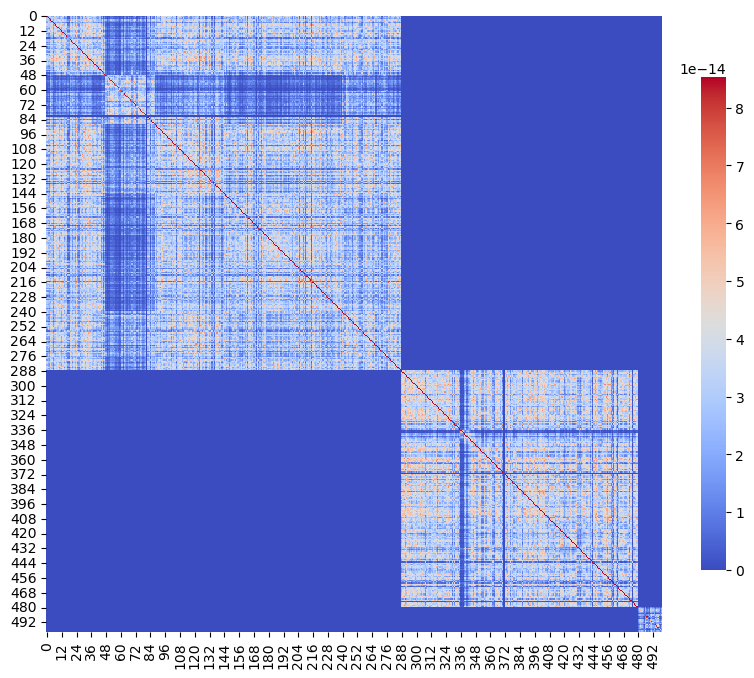

In [53]:
# plot heatmap of the learned beta prime kernel
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(bp_kernel(cov_train_all[:500], cov_train_all[:500]), annot=False, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})

In [16]:
from betaprime_python import logBetaPrimeKernelSklearnAdapter
# L = logBetaPrimeKernelSklearnAdapter(alpha=4.0, normalized = True)
L = logBetaPrimeKernelSklearnAdapter(alpha=4.0, normalized = True)
# Evaluate the classifier on the test data
L_kernel = L(cov_train_all[:], cov_train_all[:])

Computing log kernel matrix: 100%|██████████| 2496/2496 [01:18<00:00, 31.67it/s]


In [17]:
for i in range(56):
    print(f'Beta prime kernel value for sample {i+1}: {L_kernel[i, i]}')

Beta prime kernel value for sample 1: 0.0
Beta prime kernel value for sample 2: 0.0
Beta prime kernel value for sample 3: 0.0
Beta prime kernel value for sample 4: 0.0
Beta prime kernel value for sample 5: 0.0
Beta prime kernel value for sample 6: 0.0
Beta prime kernel value for sample 7: 0.0
Beta prime kernel value for sample 8: 0.0
Beta prime kernel value for sample 9: 0.0
Beta prime kernel value for sample 10: 0.0
Beta prime kernel value for sample 11: 0.0
Beta prime kernel value for sample 12: 0.0
Beta prime kernel value for sample 13: 0.0
Beta prime kernel value for sample 14: 0.0
Beta prime kernel value for sample 15: 0.0
Beta prime kernel value for sample 16: 0.0
Beta prime kernel value for sample 17: 0.0
Beta prime kernel value for sample 18: 0.0
Beta prime kernel value for sample 19: 0.0
Beta prime kernel value for sample 20: 0.0
Beta prime kernel value for sample 21: 0.0
Beta prime kernel value for sample 22: 0.0
Beta prime kernel value for sample 23: 0.0
Beta prime kernel va

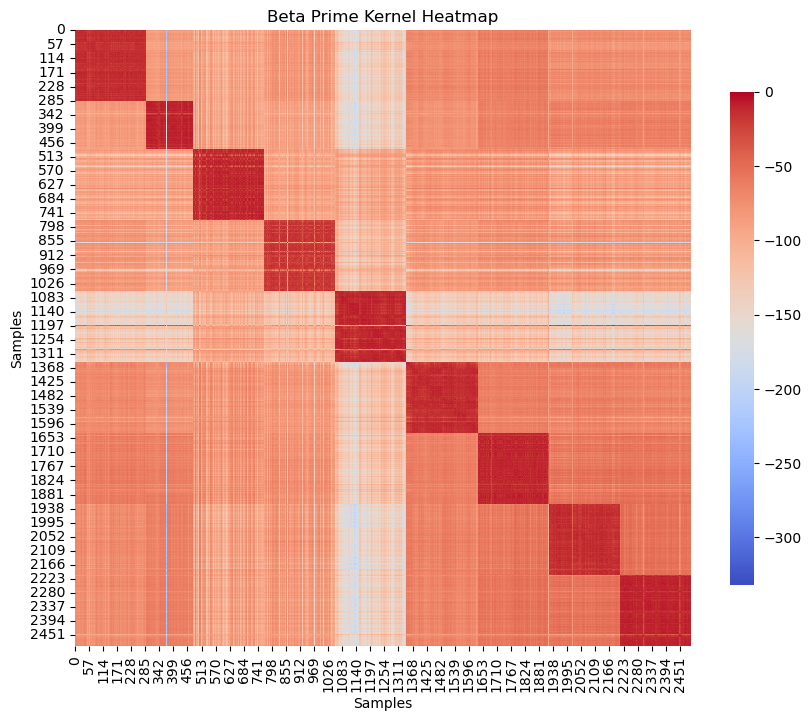

In [18]:
# Plot the heatmap of the beta prime kernel
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(L_kernel, annot=False, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Beta Prime Kernel Heatmap')
plt.xlabel('Samples')
plt.ylabel('Samples')
plt.show()

In [19]:
K = np.exp(L_kernel)

In [25]:
from sklearn.svm import SVC
# Train a classifier on the training data
clf_bp = SVC(kernel='precomputed', C=1.0, random_state=42)
clf_bp.fit(K, y_train_all)
# Evaluate the classifier on the test data
accuracy_bp = clf_bp.score(cov_test_all, y_test_all)
print(f'Accuracy of the classifier on the test data with Beta Prime kernel: {accuracy_bp * 100:.2f}% ± {np.std(accuracy_bp) * 100:.2f}%')

ValueError: Found array with dim 3. SVC expected <= 2.